In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib as plt
import pandas as pd

from pathlib import Path
import xml.etree.ElementTree as ET

# Debate Parsing

In [2]:
DEBATES_DIR = Path("data/debates")

files = list(DEBATES_DIR.glob("*.xml"))
print(f"Number of files: {len(files)}")

# print(files[0])
# print(type(files[0]))
# print()
# print(files[0].name)
# print(files[0].stem)
# print(files[0].suffix)

# print(files[0].stem[7:17]))

Number of files: 20021


In [26]:
# How to extract the year from the filename? The filename format is debatesYYYY-MM-DDa.xml, so we can extract the year by taking the substring from index 7 to 11.
years = []
for f in files:
    years.append(f.stem[7:11])

print(sorted(set(years)))

['1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']


## Tags and Attriutes

The tags and attributes of the top level root for every file in debates

In [27]:
tag_attribs = {}

for f in files:
    tree = ET.parse(f)
    root = tree.getroot()
    for child in root:
        if child.tag not in tag_attribs:
            tag_attribs[child.tag] = set()
        tag_attribs[child.tag].update(child.attrib.keys())

In [28]:
for tag in sorted(tag_attribs):
    print(tag)
    print(sorted(tag_attribs[tag]))
    print('---')

division
['colnum', 'divdate', 'divnumber', 'id', 'nospeaker', 'time', 'url']
---
gidredirect
['matchtype', 'newgid', 'oldgid']
---
inserted-heading
['colnum', 'id', 'nospeaker', 'time', 'url']
---
major-heading
['colnum', 'id', 'nospeaker', 'time', 'url']
---
minor-heading
['colnum', 'id', 'nospeaker', 'time', 'url']
---
oral-heading
['colnum', 'id', 'nospeaker', 'time', 'url']
---
speech
['colnum', 'error', 'hansard_id', 'hansard_membership_id', 'id', 'nospeaker', 'oral-qnum', 'person_id', 'redirect', 'speakerid', 'speakername', 'speakeroffice', 'time', 'type', 'url']
---


The files contain top level tags where **'speech'** contains the debate content I will use for data analysis. Division data can be obtained from the division data file and can be dropped here. The other tags can allso be dropped.
 
**Speaker ID**

Three examples of how speaker id might be saved:
- No speakername key at all (likely narrator/procedural text)
- speakername key present but empty string (a different kind of gap — maybe a redacted name, maybe a parsing quirk upstream in the source data)
- speakername key present with a real value (the normal case)

Each would need to be treated differently, how do I treat each one?

### 'speech' Attributes by Year

In [ ]:
# Attribute names per year
attribs_per_year = {}

for f in files:
    year = f.stem[7:11]

    if year not in attribs_per_year:
        attribs_per_year[year] = set()

    tree = ET.parse(f)
    root = tree.getroot()
    for child in root:
        if child.tag == 'speech':
            attribs_per_year[year].update(child.attrib.keys())

In [144]:
for i in attribs_per_year:
    print(i, sorted(attribs_per_year[i]))

1919 ['colnum', 'id', 'person_id', 'speakername', 'url']
1920 ['colnum', 'id', 'person_id', 'speakername', 'url']
1921 ['colnum', 'id', 'person_id', 'speakername', 'url']
1922 ['colnum', 'id', 'person_id', 'speakername', 'url']
1923 ['colnum', 'id', 'person_id', 'speakername', 'url']
1924 ['colnum', 'id', 'person_id', 'speakername', 'url']
1925 ['colnum', 'id', 'person_id', 'speakername', 'url']
1926 ['colnum', 'id', 'person_id', 'speakername', 'url']
1927 ['colnum', 'id', 'person_id', 'speakername', 'url']
1928 ['colnum', 'id', 'person_id', 'speakername', 'url']
1929 ['colnum', 'id', 'person_id', 'speakername', 'url']
1930 ['colnum', 'id', 'person_id', 'speakername', 'url']
1931 ['colnum', 'id', 'person_id', 'speakername', 'url']
1932 ['colnum', 'id', 'person_id', 'speakername', 'url']
1933 ['colnum', 'id', 'person_id', 'speakername', 'url']
1934 ['colnum', 'id', 'person_id', 'speakername', 'url']
1935 ['colnum', 'hansard_membership_id', 'id', 'person_id', 'speakerid', 'speakername', 

A list of attributes by year to see how the file structure chnages over time.

### person_id, speakername, and speakerid

These attributes look like they idetify the speaker, but not used consistantly through out.

What speakernames exist?

Trying to identify if any names are labelled as unknow

In [174]:
# Attribute names per year
speakernames = set()
person_ids = set()
speakerids = set()

for f in files:

    tree = ET.parse(f)
    root = tree.getroot()
    for child in root:
        if child.tag == 'speech':
            speakernames.add(child.attrib.get('speakername'))
            person_ids.add(child.attrib.get('person_id'))
            speakerids.add(child.attrib.get('speakerid'))

In [178]:
print('Person IDs: ' + str(len(person_ids)))
print('Speaker Names: ' + str(len(speakernames)))
print('Speaker IDs: ' + str(len(speakerids)))

short_names = [name for name in speakernames if name is not None and len(name) <8]
print(sorted(short_names))

short_ids = [pid for pid in person_ids if pid is not None and len(pid) < 10]
print(sorted(short_ids))

short_speakerids = [sid for sid in speakerids if sid is not None and len(sid) < 10]
print(sorted(short_speakerids))

Person IDs: 2999
Speaker Names: 47100
Speaker IDs: 12674
['', '" I ask', '. Clegg', '. Gow', '. Mann', '. Rees', '. Straw', '. VIANT', '. White', '.Mr Gow', '17.', '56', 'ADDISON', 'AMERY', 'ASHLEY', 'ASQUITH', 'Abse', 'Adley', 'Allaun', 'Amess', 'An Hon', 'Attlee', 'BENN', 'BOOTHBY', 'BOURNE', 'BROWN', 'BUXTON', 'Baird', 'Baldwin', 'Barnett', 'Beith', 'Benn', 'Bevin', 'Biffen', 'Bossom', 'Braine', 'Brown', 'Butler', 'CLYNES', 'COUPER', 'Canavan', 'Captain', 'Chapman', 'Clarke', 'Cocks', 'DAGGAR', 'DOYLE', 'Daines', 'Dalyell', 'Darling', 'Davies', 'Dobbie', 'Dobson', 'Dodds', 'Dormand', 'Dr Glyn', 'Dr Hill', 'Dr Owen', 'Dr Reid', 'Dr. Fox', 'Dr. Hll', 'Dr. Own', 'Dr. Vis', 'Dr.Owen', 'Driberg', 'EMMOTT', 'Eadie', 'Ede', 'F. HALL', 'Fisher', 'Fraser', 'G. Fox', 'GILLETT', 'GRUNDY', 'GUEST', 'Gammans', 'Gardner', 'Gower', 'Gregory', 'Grist', 'H', 'HACKING', 'HARRIS', 'HEADLAM', 'HERBERT', 'HICKS', 'HOWARD', 'Hague', 'Hale', 'Hall', 'Hannam', 'Healey', 'Hon.', 'Hooley', 'Hubbard', 'Hughes

#### speakername, person_id, and speakerid Stats

In [179]:
attrib_stats_per_year = {}

for f in files:
    year = f.stem[7:11]

    if year not in attrib_stats_per_year:
        attrib_stats_per_year[year] = {
            'total': 0,
            'person_id_missing': 0,
            'person_id_unknown': 0,
            'person_id_real': 0,
            'speakername_missing': 0,
            'speakername_empty': 0,
            'speakername_real': 0,
            'speakerid_missing': 0,
            'speakerid_unknown': 0,
            'speakerid_real': 0,
        }

    tree = ET.parse(f)
    root = tree.getroot()
    for child in root:
        if child.tag == 'speech':
            attrib_stats_per_year[year]['total'] += 1

            person_id = child.attrib.get('person_id')
            if person_id is None:
                attrib_stats_per_year[year]['person_id_missing'] += 1
            elif person_id == 'unknown' or person_id == '':
                attrib_stats_per_year[year]['person_id_unknown'] += 1
            else:
                attrib_stats_per_year[year]['person_id_real'] += 1

            speakername = child.attrib.get('speakername')
            if speakername is None:
                attrib_stats_per_year[year]['speakername_missing'] += 1
            elif speakername == '':
                attrib_stats_per_year[year]['speakername_empty'] += 1
            else:
                attrib_stats_per_year[year]['speakername_real'] += 1

            speakerid = child.attrib.get('speakerid')
            if speakerid is None:
                attrib_stats_per_year[year]['speakerid_missing'] += 1
            elif speakerid == 'unknown' or speakerid == '':
                attrib_stats_per_year[year]['speakerid_unknown'] += 1
            else:
                attrib_stats_per_year[year]['speakerid_real'] += 1  

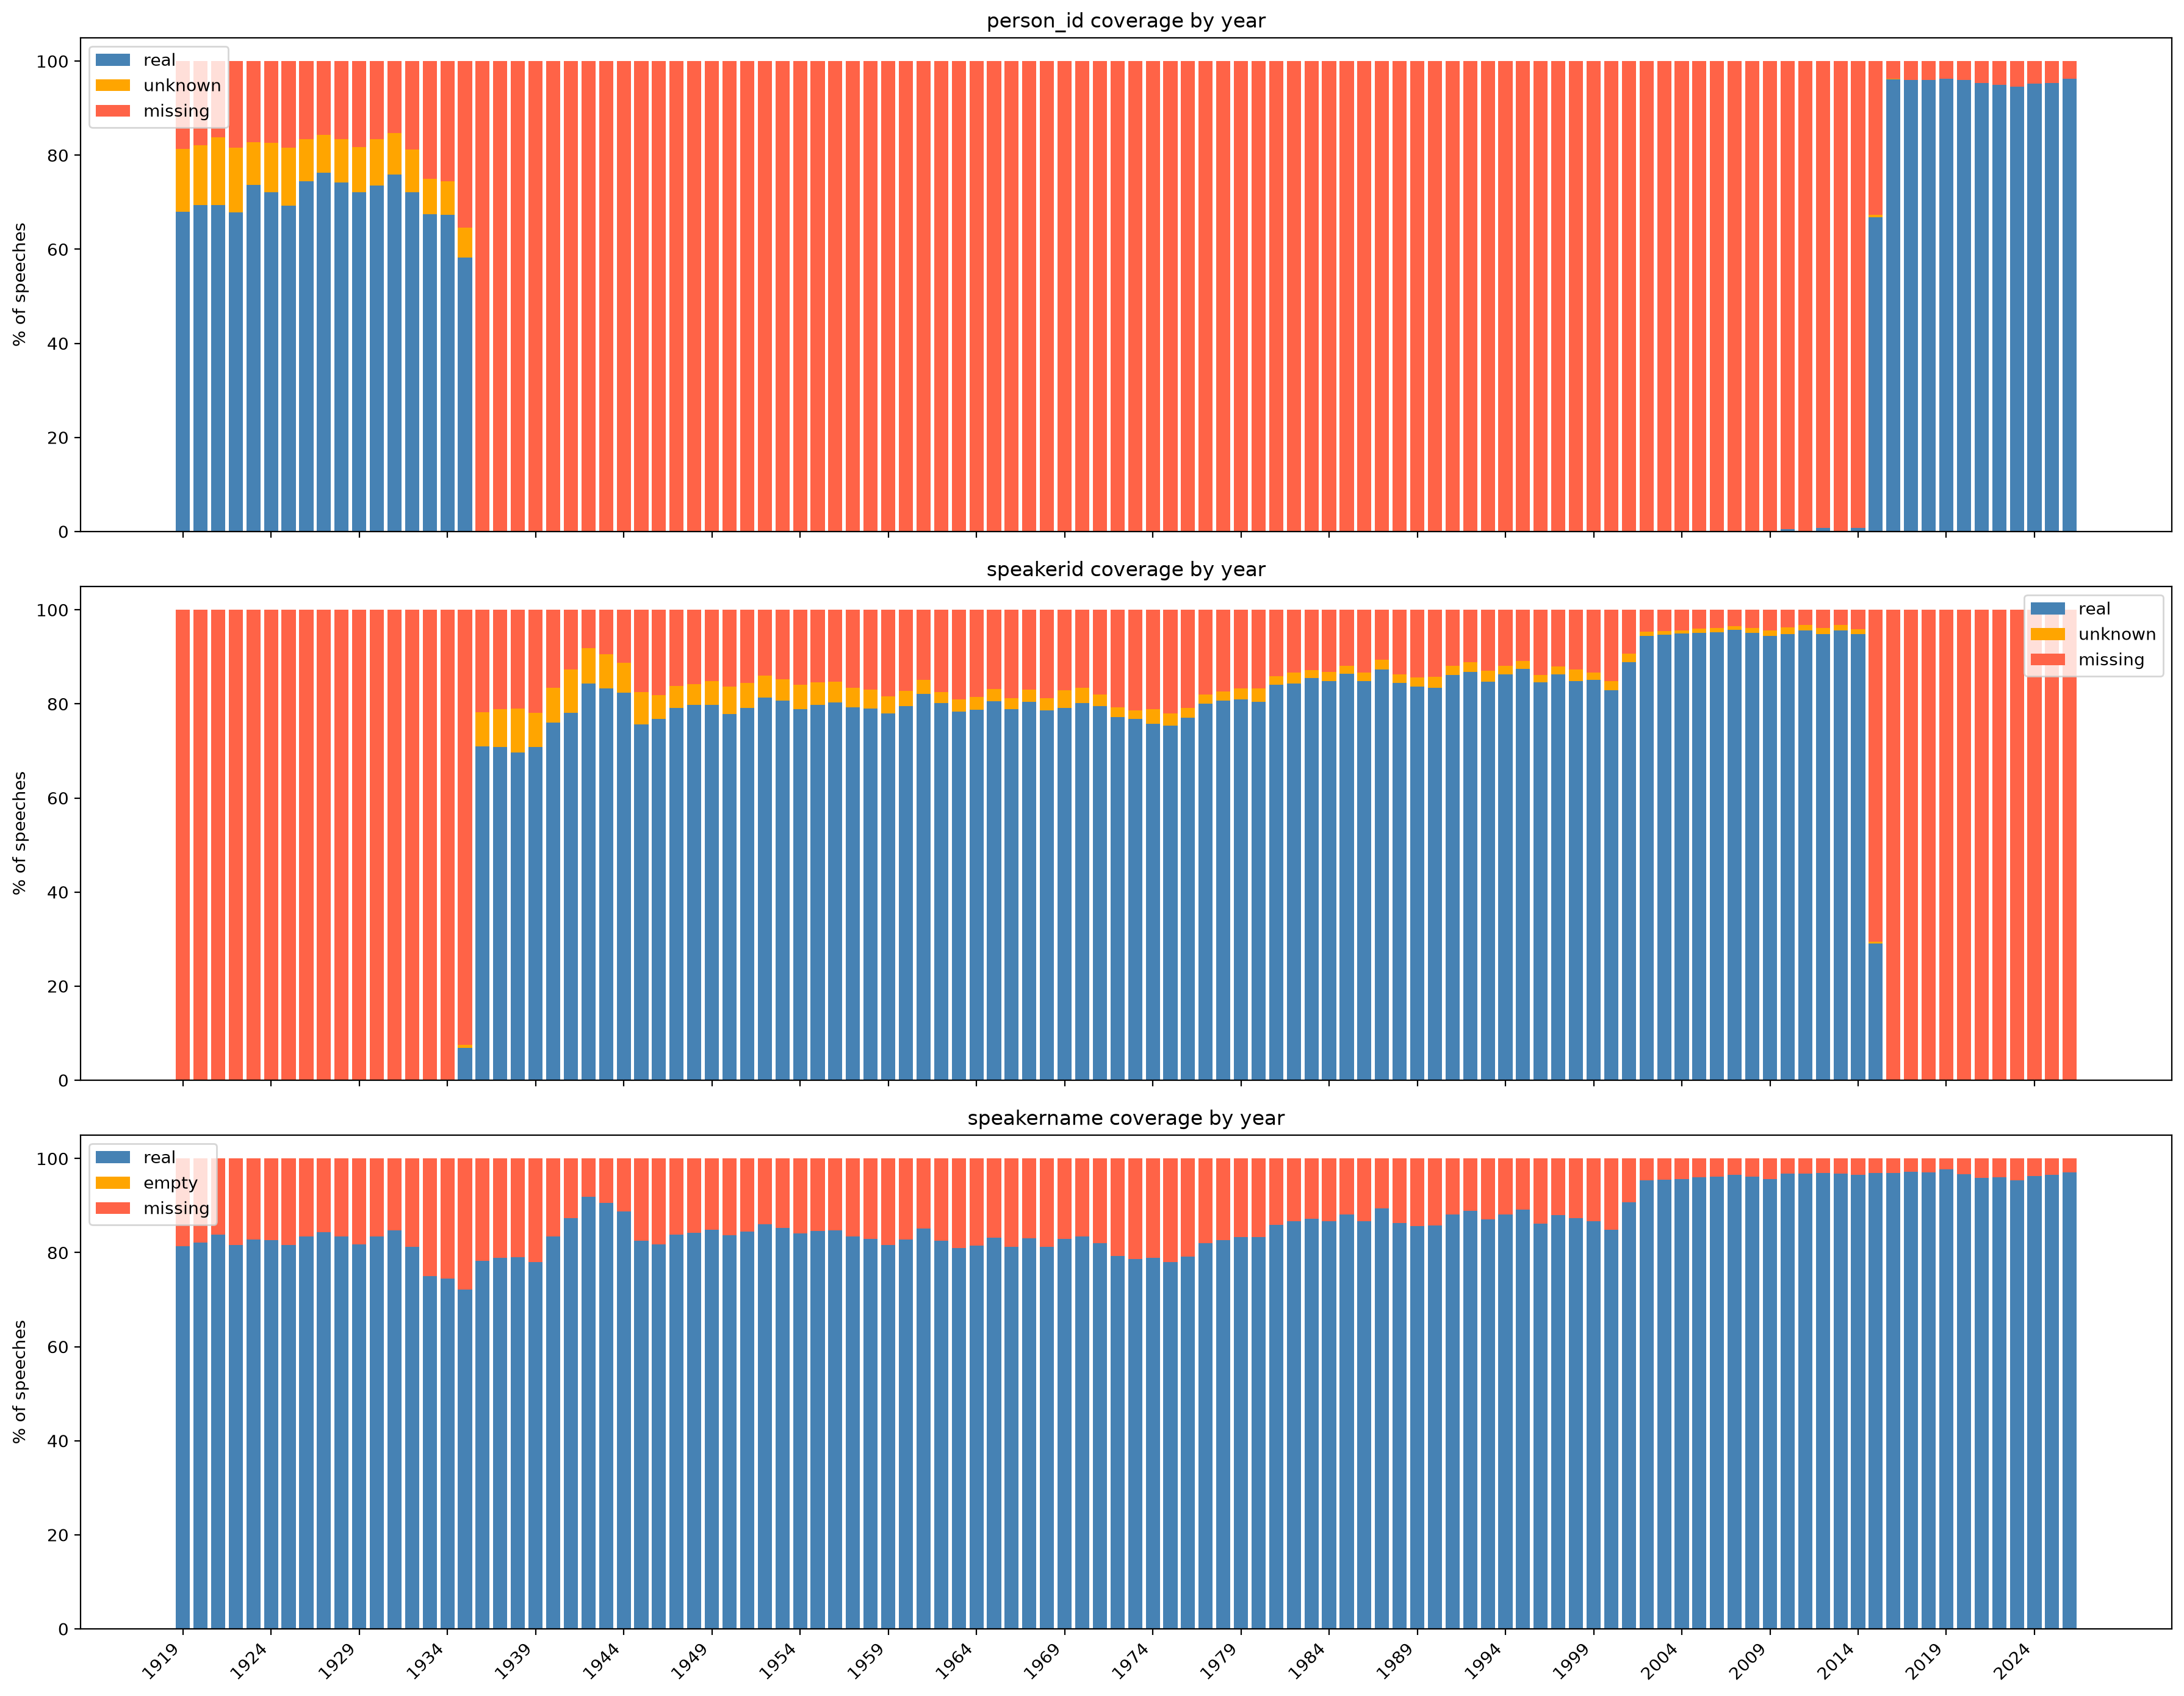

In [181]:
years = sorted(attrib_stats_per_year)

pid_real    = [100 * attrib_stats_per_year[y]['person_id_real']    / attrib_stats_per_year[y]['total'] for y in years]
pid_unknown = [100 * attrib_stats_per_year[y]['person_id_unknown'] / attrib_stats_per_year[y]['total'] for y in years]
pid_missing = [100 * attrib_stats_per_year[y]['person_id_missing'] / attrib_stats_per_year[y]['total'] for y in years]

sid_real    = [100 * attrib_stats_per_year[y]['speakerid_real']    / attrib_stats_per_year[y]['total'] for y in years]
sid_unknown = [100 * attrib_stats_per_year[y]['speakerid_unknown'] / attrib_stats_per_year[y]['total'] for y in years]
sid_missing = [100 * attrib_stats_per_year[y]['speakerid_missing'] / attrib_stats_per_year[y]['total'] for y in years]

spk_real    = [100 * attrib_stats_per_year[y]['speakername_real']    / attrib_stats_per_year[y]['total'] for y in years]
spk_empty   = [100 * attrib_stats_per_year[y]['speakername_empty']   / attrib_stats_per_year[y]['total'] for y in years]
spk_missing = [100 * attrib_stats_per_year[y]['speakername_missing'] / attrib_stats_per_year[y]['total'] for y in years]

x = np.arange(len(years))

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

axes[0].bar(x, pid_real,    label='real',    color='steelblue')
axes[0].bar(x, pid_unknown, label='unknown', color='orange',  bottom=pid_real)
axes[0].bar(x, pid_missing, label='missing', color='tomato',
            bottom=[pid_real[i] + pid_unknown[i] for i in range(len(years))])
axes[0].set_ylabel('% of speeches')
axes[0].set_title('person_id coverage by year')
axes[0].legend()

axes[1].bar(x, sid_real,    label='real',    color='steelblue')
axes[1].bar(x, sid_unknown, label='unknown', color='orange',  bottom=sid_real)
axes[1].bar(x, sid_missing, label='missing', color='tomato',
            bottom=[sid_real[i] + sid_unknown[i] for i in range(len(years))])
axes[1].set_ylabel('% of speeches')
axes[1].set_title('speakerid coverage by year')
axes[1].legend()

axes[2].bar(x, spk_real,    label='real',    color='steelblue')
axes[2].bar(x, spk_empty,   label='empty',   color='orange',  bottom=spk_real)
axes[2].bar(x, spk_missing, label='missing', color='tomato',
            bottom=[spk_real[i] + spk_empty[i] for i in range(len(years))])
axes[2].set_ylabel('% of speeches')
axes[2].set_title('speakername coverage by year')
axes[2].legend()

plt.xticks(x[::5], years[::5], rotation=45, ha='right')
plt.tight_layout()
plt.show()

**person_id** there is about 70% coverage from 1919 to 1935 with about 10% of the coverage being unkonwn. The attribute is then not used in the data from 1936 to 2015. After 2015 the attribute is used again with no unknows and +90% coverage.

**speakername** has much more consistant coverage with coverage sittign around 80% up to 2003 where it then jumps to +90% so a very useful attribute.

**speakerid** used as the id between 1936 and 2015 around 80% again, jumping up in coverage around 2002

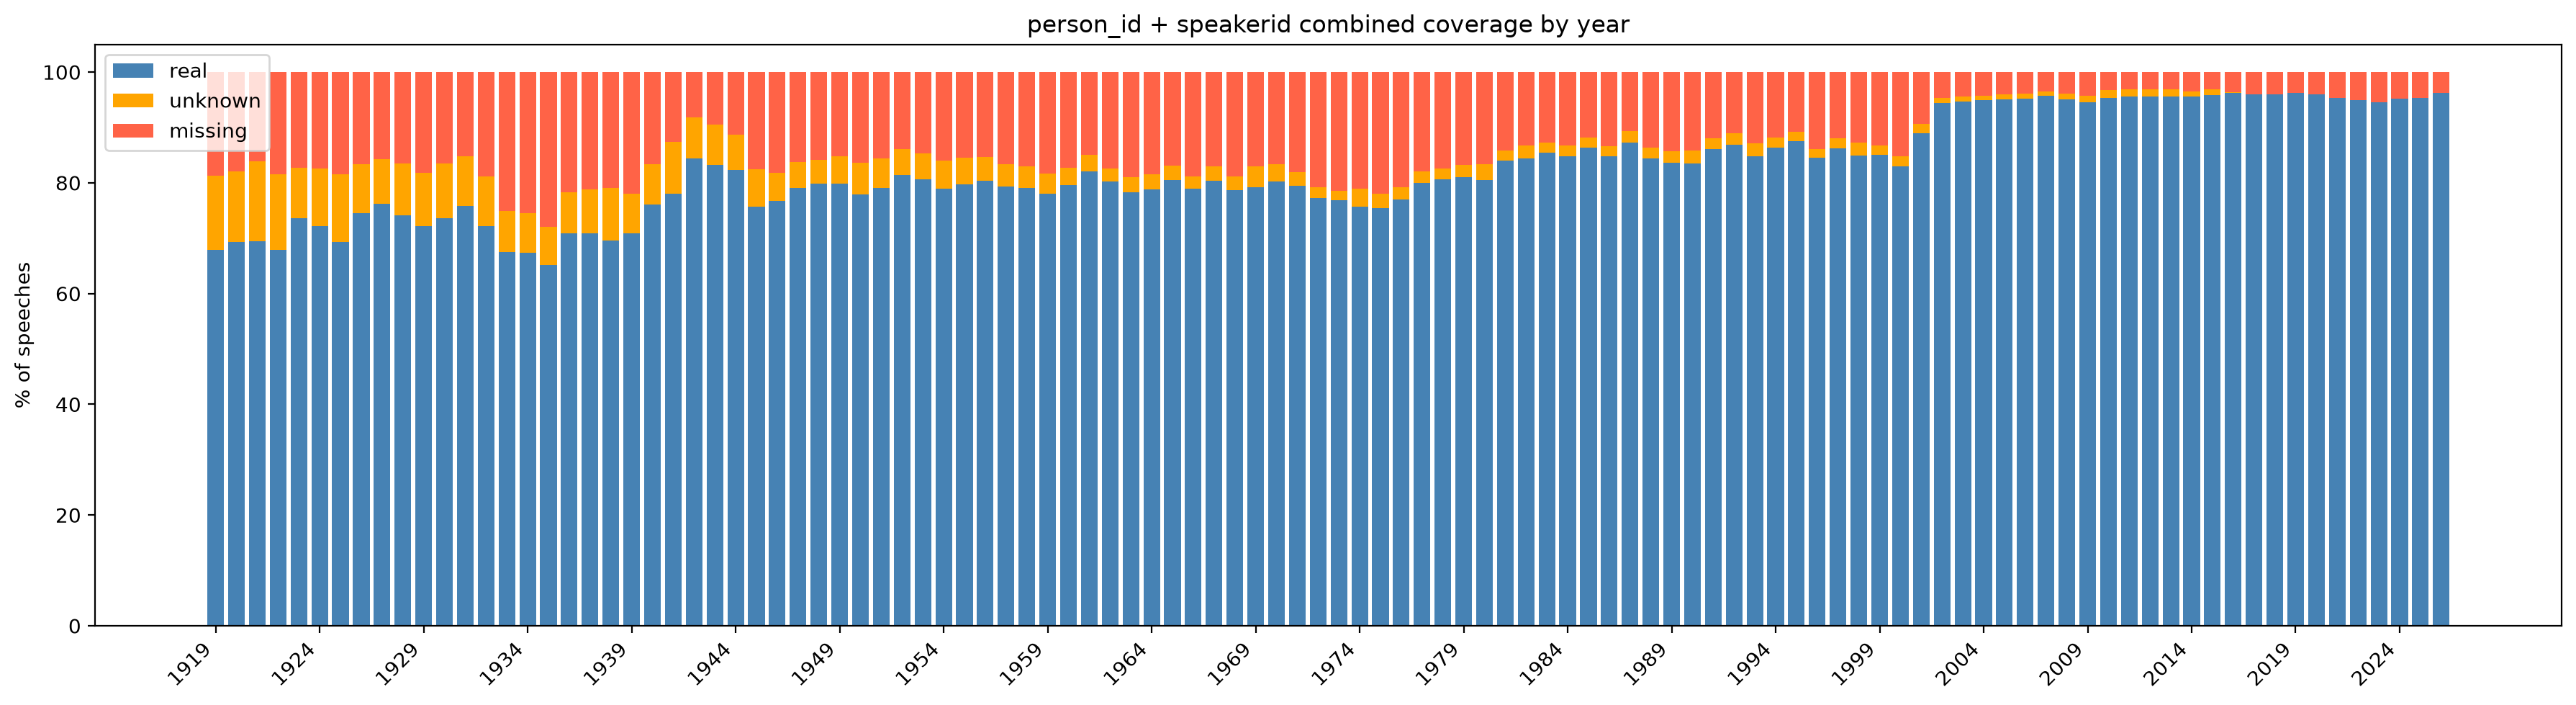

In [183]:
combined_real    = [100 * (attrib_stats_per_year[y]['person_id_real'] + attrib_stats_per_year[y]['speakerid_real']) / attrib_stats_per_year[y]['total'] for y in years]
combined_unknown = [100 * (attrib_stats_per_year[y]['person_id_unknown'] + attrib_stats_per_year[y]['speakerid_unknown']) / attrib_stats_per_year[y]['total'] for y in years]
combined_missing = [100 - combined_real[i] - combined_unknown[i] for i in range(len(years))]

fig, ax = plt.subplots(figsize=(18, 5))

ax.bar(x, combined_real,    label='real',    color='steelblue')
ax.bar(x, combined_unknown, label='unknown', color='orange',  bottom=combined_real)
ax.bar(x, combined_missing, label='missing', color='tomato',
       bottom=[combined_real[i] + combined_unknown[i] for i in range(len(years))])
ax.set_ylabel('% of speeches')
ax.set_title('person_id + speakerid combined coverage by year')
ax.legend()

plt.xticks(x[::5], years[::5], rotation=45, ha='right')
plt.tight_layout()
plt.show()

so either person_id or speakerid can be used for idetification but they need to be saved seperately as they link out in different ways

### do any files have both speakerid and person_id?

In [4]:
both_count = 0
both_examples = []

for f in files:
    tree = ET.parse(f)
    root = tree.getroot()
    for child in root:
        if child.tag == 'speech':
            has_pid = 'person_id' in child.attrib
            has_sid = 'speakerid' in child.attrib
            if has_pid and has_sid:
                both_count += 1
                if len(both_examples) < 5:
                    both_examples.append((f.name, child.attrib.get('person_id'), child.attrib.get('speakerid')))

print(f"speeches with both: {both_count}")
for ex in both_examples:
    print(ex)

speeches with both: 0


### Other Attributes

nospeaker, type, hansard_id, hansard_membership_id, speakeroffice, error, oral-qnum, redirect, and time.

In [30]:
records = []

for f in files:
    year = int(f.stem[7:11])
    tree = ET.parse(f)
    root = tree.getroot()
    for child in root:
        if child.tag == 'speech':
            records.append({
                'year': year,
                'file': f.name,
                **child.attrib,  # grabs everything, you filter later
                'text_snippet': ''.join(child.itertext())[:150]
            })

In [ ]:
attribs = ['colnum', 'error', 'hansard_id', 'hansard_membership_id', 'id', 'nospeaker', 'oral-qnum', 'redirect', 'speakeroffice', 'time', 'type']

survey = {attr: {'values': set(), 'examples': {}, 'files': set()} for attr in attribs}

for record in records:
    for attr in attribs:
        val = record.get(attr)
        if val is not None and val != '':
            survey[attr]['values'].add(val)
            survey[attr]['files'].add(record['file'])
            if val not in survey[attr]['examples']:
                survey[attr]['examples'][val] = record.get('text_snippet', '')[:80]

for attr in attribs:
    vals = sorted(survey[attr]['values'])
    n_vals = len(vals)
    n_files = len(survey[attr]['files'])
    print(f"\n{'='*60}")
    print(f"  {attr.upper()}  |  {n_vals} distinct values  |  {n_files} files")
    print(f"{'='*60}")
    for v in vals[:20]:
        print(f"  '{v}' | {survey[attr]['examples'][v]}")


  COLNUM  |  3620 distinct values  |  19271 files
  ' 370' | 
To ask the Secretary of State for National Heritage what progress is being made
  '1' | 
The House met at a Quarter before Three of the Clock, being the first day of th
  '10' | 
The House having again unanimously called Mr. James William, Lowther to the
Cha
  '100' | 
I am very glad the right hon. Gentleman knows that. In the North not only are t
  '1000' | 
Amendment to the proposed Amendment negatived.

  '1001' | 
The position is exactly as the hon. Member has described.

  '1002' | 
Is machinery to be treated as a manufactured article?

  '1003' | 
On a point of Order, Sir. May I ask whether, if the Amendment moved by my right
  '1004' | 
May I just point out that my right hon. Friend quite unintentionally, I am sure
  '1005' | 
That bears out what I say—that he does not wish any facilities for further legi
  '1006' | 
That point would be met by notice being given the day before.

  '1007' | 
The proposal that the Gove

colnum: no analytical value so can be dropped.

nospeaker: has 1 distic value across 4232 file but it appears so speeches arent worth keeping so will keep to remove later

type: type give speech-type classification from 2018 onwards so worth including.

hansard: Both hansard_id and hansard_membership_id can be dropped as i dont know what they link to and dont have those files currently so are not needed.

speakeroffice: It only exists between 2001 and 2016 and not useful enoguh to include.

error: will not keep error as it is just a data quality flag and only spans 15 years like speakeroffice

oral-qnum: oral_qnum will be kep as its been inlduded sine 2001 cannot be reconstrctued from raw text alone. will need clearning

redirect: not useful to keep

time: will keep but will need processing as there appears to be a leading 0

## Speech Content Tags and Attributes

In [34]:
speech_child_tags = set()

for f in files:
    tree = ET.parse(f)
    root = tree.getroot()
    for speech in root.findall('speech'):
        for elem in speech.iter():
            speech_child_tags.add(elem.tag)

print(speech_child_tags)

{'a', 'caption', 'sup', 'tr', 'I', 'table', 'phrase', 'span', 'u', 'div', 'p', 'td', 'speech', 'col', 'br', 'tbody', 'SUB', 'ob', 'lb', 'membercontribution', 'li', 'memberconstituency', 'i', 'q', 'ul', 'th', 'img', 'session', 'b', 'sub', 'ol', 'member'}


In [ ]:
target_tags = {'a', 'caption', 'sup', 'tr', 'I', 'table', 'phrase', 'span', 
               'u', 'div', 'p', 'td', 'col', 'br', 'tbody', 'SUB', 'ob', 'lb', 
               'membercontribution', 'li', 'memberconstituency', 'i', 'q', 'ul', 
               'th', 'img', 'session', 'b', 'sub', 'ol', 'member'}


tag_records = {tag: [] for tag in target_tags}

for f in files:
    tree = ET.parse(f)
    root = tree.getroot()
    for speech in root.findall('speech'):
        for elem in speech.iter():
            if elem.tag in target_tags and len(tag_records[elem.tag]) < 3:
                tag_records[elem.tag].append(ET.tostring(elem, encoding='unicode')[:400])

In [37]:
for tag in sorted(tag_records):
    print(f"\n{'='*50}\n  {tag}\n{'='*50}")
    for example in tag_records[tag]:
        print(example)
        print('---')


  I
<I>'Registered Designs Act 1949 (c. 88)</I>
---

  SUB
<SUB>F</SUB>—and the net saving, if any, calculated as That will indicate an overall percentage greenhouse gas saving, and the biofuel in question should be considered sustainable only if the percentage saving is significant.
---

  a
<a name="S5CV0112P0_19190213_HOC_358">  </a>

---
<a name="S5CV0112P0_19190217_HOC_425">  </a>

---
<a name="S5CV0112P0_19190219_HOC_535">  </a>

---

  b
<b>Division No. 2.]</b>
---
<b>AYES.</b>
---
<b>6.56 p.m.</b>
---

  br
<br />
I want, for a very short time, to give some consideration to what those qualities and qualifications are. First, I think that the occupant of the Chair has to have Standing Orders at his finger tips; he has to know them, at any rate, better than any other man or woman in the House, with the possible exception of the learned Clerk. He has also to have something which is more indefinable. He 
---
<br />
Then, again, he has to take decisions on the spur of the moment. W

div, table, tr, td, th, tbody, caption, a, img and col can be stripped as not speech content.

i, I, b, u, sub, SUB, sup, br, lb, ob, p, ol, ul and li are text formatting and will be kept

In [40]:
p_examples = []
phrase_examples = []

for f in files:
    if len(p_examples) >= 3 and len(phrase_examples) >= 3:
        break
    tree = ET.parse(f)
    root = tree.getroot()
    for speech in root.findall('speech'):
        for elem in speech.iter():
            if elem.attrib.get('pwmotiontext') == 'yes':
                if elem.tag == 'p' and len(p_examples) < 3:
                    p_examples.append(ET.tostring(elem, encoding='unicode')[:400])
                elif elem.tag == 'phrase' and len(phrase_examples) < 3:
                    phrase_examples.append(ET.tostring(elem, encoding='unicode')[:400])

print("=== p pwmotiontext=yes ===")
for ex in p_examples:
    print(ex)
    print('---')

print("=== phrase pwmotiontext=yes ===")
for ex in phrase_examples:
    print(ex)
    print('---')

=== p pwmotiontext=yes ===
<p pid="a.698.2/1" class="" pwmotiontext="yes">I beg to move, That the Bill be now read a Second time.</p>
	
---
<p pid="a.698.2/2" class="" pwmotiontext="yes">My right hon. Friend the Secretary of State for Health has written to you, Mr. Speaker, and to <phrase class="honfriend" id="uk.org.publicwhip/member/213" name="Liam Fox">the hon. Member for Woodspring (Dr. Fox)</phrase> to express his apologies for being unable to be present due to a long-standing constituency engagement.</p>
	
---
<p pid="a.777.1/1" class="" pwmotiontext="yes">I beg to move,</p>
	
---
=== phrase pwmotiontext=yes ===
<phrase class="standing-order" code="33" title="Calling of amendments at end of debate" pwmotiontext="yes">Standing Order No. 33 (Calling of amendments at end of debate)</phrase>, That the amendment be made:--
---
<phrase class="standing-order" code="33" title="Calling of amendments at end of debate" pwmotiontext="yes">Standing Order No. 33 (Calling of amendments at end o

In [41]:
p_count = 0
phrase_count = 0

for f in files:
    tree = ET.parse(f)
    root = tree.getroot()
    for speech in root.findall('speech'):
        for elem in speech.iter():
            if elem.attrib.get('pwmotiontext') == 'yes':
                if elem.tag == 'p':
                    p_count += 1
                elif elem.tag == 'phrase':
                    phrase_count += 1

print(f"p pwmotiontext=yes: {p_count}")
print(f"phrase pwmotiontext=yes: {phrase_count}")

p pwmotiontext=yes: 106775
phrase pwmotiontext=yes: 1311


### Text Extraction Within speech

1. Strip the non-speech tags entirely (div, table, tr, td, th, tbody, caption, a, img, col)
2. Run itertext on everything else

## Debates Attributes Summary

**Top-level tags:** every file has `major-heading`, `minor-heading`, `speech` (all 107 years). From 2001+: `division`, `oral-heading`, `gidredirect`, `inserted-heading` — none carry speech content or speaker attribution, so the parser filters to `speech` tags only.

**Speech attributes kept:**

| Attribute | Years | Notes |
|---|---|---|
| `id` | all | speech-level reference ID |
| `url` | all | source link |
| `time` | 1935+ | `HH:MM:SS`, sometimes empty; needs cleaning — malformed leading zero on hour in some values |
| `person_id` | 1919–1934, then 2010–present | links to `people.json`; transition year 1935 has both `person_id` and `speakerid` |
| `speakerid` | 1935–2017 | links to membership records, different namespace from `person_id`; overlaps with `person_id` again 2010–2015 |
| `speakername` | all | ~80–95% coverage, not unique enough alone for party-joining |
| `nospeaker` | 2001+ | single value `true` across 4232 files; kept to filter procedural speeches downstream |
| `type` | 2018+ | Speech/Question/Answer/Intervention/Chair/PointOfOrder, Start/Continuation |
| `oral-qnum` | 2001+ | question number within oral questions session; needs cleaning — trailing periods and newlines in some values |

**Dropped:** `colnum` (column number from printed Hansard, no analytical value), `hansard_id` / `hansard_membership_id` (unresolvable reference IDs, no source files), `speakeroffice` (narrow 2001–2016 window, not useful enough to include), `error` (data-quality flag, narrow 15-year window, marginal), `redirect` (placeholder rows, text literally "NOTHING").

**person_id vs speakerid:** kept as separate columns — different ID namespaces, never co-occur on the same speech (confirmed: 0 speeches with both across full corpus).

**Coverage:** combined `person_id` + `speakerid` real-value coverage rises from ~70% (1919) to ~95%+ (2000+). No rows dropped for missing identifiers — kept nullable, filtered per downstream task as needed.

**Speech text extraction:** strip `div`, `table`, `tr`, `td`, `th`, `tbody`, `caption`, `a`, `img`, `col` entirely (voting tables, anchors, images, column markers). Itertext everything else — no attribute-based exclusions.

# Parser

In [3]:
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
import re
import glob

STRIP_TAGS = {'div', 'table', 'tr', 'td', 'th', 'tbody', 'caption', 'a', 'img', 'col'}

def extract_text(elem):
    parts = []
    if elem.tag in STRIP_TAGS:
        return parts
    if elem.text:
        parts.append(elem.text)
    for child in elem:
        parts.extend(extract_text(child))
        if child.tail:
            parts.append(child.tail)
    return parts

def get_speech_text(speech_elem):
    parts = extract_text(speech_elem)
    return ' '.join(p.strip() for p in parts if p.strip())

def clean_time(val):
    if not val:
        return None
    match = re.match(r'^0*(\d+):(\d{2}):(\d{2})$', val.strip())
    if match:
        h, m, s = match.groups()
        return f"{int(h):02d}:{m}:{s}"
    return None

def clean_oral_qnum(val):
    if not val:
        return None
    return val.strip().rstrip('.')

rows = []
chunk_size = 2000
chunk_num = 0

for i, f in enumerate(files):
    if i % 1000 == 0:
        print(f"{i}/{len(files)} — {len(rows)} rows so far")

    date_match = re.search(r'(\d{4}-\d{2}-\d{2})', f.name)
    if not date_match:
        continue
    date = date_match.group(1)
    year = int(date[:4])

    try:
        root = ET.parse(f).getroot()
    except ET.ParseError as e:
        print(f"skip {f.name}: {e}")
        continue

    for speech in root.findall('speech'):
        a = speech.attrib
        rows.append({
            'id':          a.get('id'),
            'date':        date,
            'year':        year,
            'url':         a.get('url'),
            'time':        clean_time(a.get('time')),
            'person_id':   a.get('person_id'),
            'speakerid':   a.get('speakerid'),
            'speakername': a.get('speakername'),
            'nospeaker':   a.get('nospeaker'),
            'type':        a.get('type'),
            'oral_qnum':   clean_oral_qnum(a.get('oral-qnum')),
            'text':        get_speech_text(speech),
        })

    if (i + 1) % chunk_size == 0:
        pd.DataFrame(rows).to_parquet(f'data/debates_chunk_{chunk_num}.parquet', index=False)
        print(f"  wrote chunk {chunk_num}")
        rows = []
        chunk_num += 1

# write remaining rows
if rows:
    pd.DataFrame(rows).to_parquet(f'data/debates_chunk_{chunk_num}.parquet', index=False)

# concatenate chunks
chunks = sorted(glob.glob('data/debates_chunk_*.parquet'))
df = pd.concat([pd.read_parquet(c) for c in chunks])
df.to_parquet('data/debates.parquet', index=False)
print(f"saved {len(df):,} rows")

for c in chunks:
    Path(c).unlink()

0/20021 — 0 rows so far
1000/20021 — 432348 rows so far
  wrote chunk 0
2000/20021 — 0 rows so far
3000/20021 — 432444 rows so far
  wrote chunk 1
4000/20021 — 0 rows so far
5000/20021 — 474567 rows so far
  wrote chunk 2
6000/20021 — 0 rows so far
7000/20021 — 456098 rows so far
  wrote chunk 3
8000/20021 — 0 rows so far
9000/20021 — 442276 rows so far
  wrote chunk 4
10000/20021 — 0 rows so far
11000/20021 — 427496 rows so far
  wrote chunk 5
12000/20021 — 0 rows so far
13000/20021 — 353782 rows so far
  wrote chunk 6
14000/20021 — 0 rows so far
15000/20021 — 206614 rows so far
  wrote chunk 7
16000/20021 — 0 rows so far
17000/20021 — 240462 rows so far
  wrote chunk 8
18000/20021 — 0 rows so far
19000/20021 — 158408 rows so far
  wrote chunk 9
20000/20021 — 0 rows so far
saved 6,944,177 rows


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('data/debates.parquet', columns=['year'])

speech_count = df.groupby('year').size()

plt.figure(figsize=(14, 5))
plt.plot(speech_count.index, speech_count.values)
plt.xlabel('Year')
plt.ylabel('Speech count')
plt.title('Speeches per year')
plt.tight_layout()
plt.show()